In [1]:
import pandas as pd
import numpy as np
import json
from tqdm import tqdm

In [2]:
from display import visualize_moment
from gather import get_event_logs, get_logs, possession_team
from process import ProcessedMoment
from event import Event, Game, Season

In [4]:
with open("games/0021500438.json") as f:
    game = json.load(f)

In [5]:
print(game.keys())
print(len(game['events']))
print(game['events'][0].keys())
print(len(game['events'][0]['moments']))
print(len(game['events'][0]['moments'][0]))

print("-------------")
for val in game['events'][0]['moments'][0]:
    print(val)

dict_keys(['gameid', 'gamedate', 'events'])
493
dict_keys(['eventId', 'visitor', 'home', 'moments'])
149
6
-------------
1
1451082035065
720.0
24.0
None
[[-1, -1, 46.25174, 27.56612, 3.4819], [1610612744, 101106, 50.28268, 26.11096, 0.0], [1610612744, 201575, 50.28268, 26.11096, 0.0], [1610612744, 201939, 77.69071, 24.66218, 0.0], [1610612744, 202691, 49.74069, 32.55629, 0.0], [1610612744, 203110, 58.22998, 24.8341, 0.0], [1610612739, 2544, 43.90252, 15.81125, 0.0], [1610612739, 2747, 45.66055, 32.43427, 0.0], [1610612739, 201567, 36.68877, 24.80455, 0.0], [1610612739, 202681, 45.66055, 32.43427, 0.0], [1610612739, 202389, 44.76942, 25.42155, 0.0]]


In [6]:
Event(game['events'][11])

In [7]:
gm = Game(game)

In [8]:
# ev_logs, ev_idx, nerr = get_event_logs(game['events'][128], bound_start=599.09)

# print(len(ev_logs), nerr)

# possession_team(ev_logs)

In [9]:
gm.errors

[]

In [10]:
len(gm.errors), len(gm.events)

(0, 186)

In [11]:
rng = np.random.default_rng(seed=123)

grav = {}

for pl in gm.home['players'] + gm.away['players']:
    pl_id = pl['playerid']
    grav[pl_id] = np.exp(rng.normal())
for i in [-1,-2]:
    grav[i] = np.exp(rng.normal())

grav

{101106: 0.37190332022766404,
 203105: 0.692264859626372,
 203949: 3.6252572861920394,
 202691: 1.2140652257174613,
 203110: 2.5098698510797406,
 201574: 1.7808731740733474,
 201575: 0.5291604175163883,
 201578: 1.719360157926617,
 201939: 0.7286254600908438,
 203546: 0.7244162534103393,
 2733: 1.1020447508582012,
 2738: 0.21741867497857714,
 2571: 3.2942090845438883,
 201567: 0.5111512853419641,
 202389: 2.719014285688344,
 202684: 1.1460498584569652,
 202681: 4.627575494406395,
 202697: 0.5168671432559776,
 203099: 0.7321317049063288,
 2747: 1.4018168237682436,
 2760: 0.1099784217656231,
 203521: 2.2885568938405654,
 2544: 4.6722015972467865,
 2210: 3.0857871946917292,
 2590: 2.127121472384754,
 2592: 0.8641768072305801,
 -1: 3.603487862269787,
 -2: 2.9271540059968646}

In [12]:
gm.loss(grav, 0.2, 2)

5541648.342245426

In [13]:
gm.events[0].loss(grav, 0.2, 2)

7190.898938063975

In [14]:
gm.events[0].moments[0].loss(grav, 0.2, 2)

419.43185353778756

In [15]:
gm.events[0].moments[0].resid(grav, 0.2, 2)

{101106: array([ 5.47629787, -7.26133865]),
 201575: array([0.2830633 , 1.87490727]),
 201939: array([-0.41804606,  0.13946391]),
 202691: array([8.5809158 , 1.53379804]),
 203110: array([15.85300006, -2.37130726])}

In [18]:
gm.events[0].moments[0].def_loc

{101106: array([79.18133, 31.84306]),
 201575: array([64.70901, 26.64668]),
 201939: array([75.40104, 21.66398]),
 202691: array([66.71983, 11.21139]),
 203110: array([79.11448, 31.79202])}

In [19]:
gm.events[0].moments[0].predicted_locations(grav)

{101106: array([73.70503213, 39.10439865]),
 201575: array([64.4259467 , 24.77177273]),
 201939: array([75.81908606, 21.52451609]),
 202691: array([58.1389142 ,  9.67759196]),
 203110: array([63.26147994, 34.16332726])}

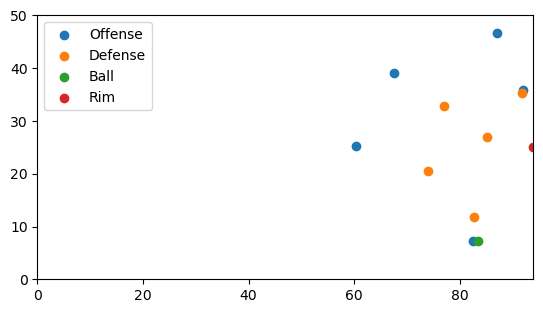

In [20]:
EVENT_IDX = 0
MOMENT_IDX = 30

visualize_moment(gm.events[EVENT_IDX].logs[MOMENT_IDX], gm.events[EVENT_IDX].poss_team)

In [21]:
gm.events[EVENT_IDX].moments[MOMENT_IDX].assignments()

[4, 0, 1, 3, 2]

In [22]:
gm.events[EVENT_IDX].moments[MOMENT_IDX].poss_team_id

1610612739

In [23]:
gm.events[EVENT_IDX].logs[MOMENT_IDX].location_list()

[[-1, -1, array([83.45005,  7.26193])],
 [1610612744, 101106, array([85.17909, 26.92054])],
 [1610612744, 201575, array([82.70822, 11.87114])],
 [1610612744, 201939, array([73.93154, 20.50619])],
 [1610612744, 202691, array([91.8333 , 35.33461])],
 [1610612744, 203110, array([77.10075, 32.91142])],
 [1610612739, 2544, array([82.56018,  7.33288])],
 [1610612739, 2747, array([60.33217, 25.27593])],
 [1610612739, 201567, array([67.58892, 39.05621])],
 [1610612739, 202681, array([87.12249, 46.61179])],
 [1610612739, 202389, array([92.10483, 35.93942])]]

# Temp

In [1]:
import pandas as pd
import numpy as np
import json
from tqdm import tqdm

In [2]:
from display import visualize_moment
from gather import get_event_logs, get_logs, possession_team
from process import ProcessedMoment
from event import Event, Game, Season

In [3]:
with open("games/0021500438.json") as f:
    game = json.load(f)

In [4]:
season = Season([game])

In [5]:
AtA, Atb, btb, lst = season.normal_equation_terms()

In [6]:
AtA.shape, Atb.shape, len(lst)

((24, 24), (24,), 24)

In [7]:
m = np.linalg.solve(AtA, Atb)
m

array([ 3.50727392,  6.72746063, 10.7061455 ,  5.62722824,  6.5578547 ,
        3.56681276,  7.14885395,  2.91394811,  4.20008464, -0.715438  ,
        2.5540154 ,  2.66513095,  6.67270313, 11.4509744 ,  0.65342235,
        9.61045179,  4.38031412,  9.09799027,  3.72678468,  4.30778821,
        6.44273571, 12.0606089 , 13.49868697,  3.38681184])

In [9]:
m, lst, ls = season.solve_mass(rim_weight=0.2, p=2, alpha=1.)
m

array([ 3.23189569,  6.74847047, 10.60924703,  5.36761376,  6.31377501,
        3.34460992,  7.01640016,  2.82712936,  4.11320166, -0.76242908,
        2.49560321,  2.57692459,  6.47555613, 11.31818496,  0.59396956,
        9.48472107,  4.31639756,  8.98291138,  3.63933665,  4.23468434,
        6.34861851, 11.92868509, 12.72109029,  3.22566098])

In [10]:
grav2 = {a : b for (a,b) in zip(lst, m)}

season.loss(grav2, rim_weight=0.2, p=2)

5429841.204005198

In [11]:
ls

5438458.99833367

In [12]:
grav2

{-2: 3.2318956916663053,
 -1: 6.748470466851204,
 2544: 10.609247029319736,
 2571: 5.367613757295271,
 2590: 6.3137750128256105,
 2592: 3.344609923820231,
 2733: 7.016400164968978,
 2738: 2.8271293588263204,
 2747: 4.113201662818889,
 101106: -0.7624290828156153,
 201567: 2.4956032084852677,
 201575: 2.5769245859386705,
 201578: 6.475556128948435,
 201939: 11.318184959771122,
 202389: 0.5939695605782879,
 202681: 9.484721070834516,
 202684: 4.316397564065557,
 202691: 8.982911378092838,
 202697: 3.63933665284133,
 203105: 4.234684342232753,
 203110: 6.3486185092100955,
 203521: 11.92868508868159,
 203546: 12.721090287106033,
 203949: 3.225660981797946}

In [13]:
season.loss(grav, rim_weight=0.2, p=2)

NameError: name 'grav' is not defined

In [14]:
name_to_grav = {}

for player in season.games[0].away['players'] + season.games[0].home['players']:
    if player['playerid'] not in grav2:
        continue
    name = f"{player['firstname']} {player['lastname']}"
    name_to_grav[name] = np.round(grav2[player['playerid']],2)
    # print(f"{player['firstname']} {player['lastname']}: {np.round(grav2[player['playerid']],2)}")

for name, grav in sorted(name_to_grav.items(), key = lambda x : x[1], reverse=True):
    print(f"{name}: {grav}")

Ian Clark: 12.72
Matthew Dellavedova: 11.93
Stephen Curry: 11.32
LeBron James: 10.61
Kyrie Irving: 9.48
Klay Thompson: 8.98
Shaun Livingston: 7.02
Marreese Speights: 6.48
Draymond Green: 6.35
Mo Williams: 6.31
Leandro Barbosa: 5.37
Tristan Thompson: 4.32
Festus Ezeli: 4.23
J.R. Smith: 4.11
Iman Shumpert: 3.64
James Jones: 3.34
James Michael McAdoo: 3.23
Andre Iguodala: 2.83
Brandon Rush: 2.58
Kevin Love: 2.5
Timofey Mozgov: 0.59
Andrew Bogut: -0.76


# Minimization starter code

A few things to do:
- use scipy optimize to find best exponential power (p) and rim weight
- Iterate between solving for off player masses and rim weight / p params

In [ ]:
def objective(theta):

    gravity = {
        pid: np.exp(val)
        for pid, val in zip(player_ids, theta)
    }

    loss = sum(moment.loss(gravity) for moment in moments)

    reg = 0.01*np.sum(theta**2)

    return loss + reg

In [ ]:
from scipy.optimize import minimize

def objective(x):

    gravity = dict(zip(player_ids, x))

    return sum(moment.loss(gravity) for moment in moments)

x0 = np.ones(len(player_ids))

result = minimize(objective, x0)

gravity_hat = dict(zip(player_ids, result.x))